In [1]:
# 24.08.2026 - Homola jeszcze nie odpisal na prosbe o konsultacje z konca
# 20260823.txt. Maciek chce pracowac dalej - ten notebook to TANI KOMPLEMENT
# do trzech zbieznych sygnalow z 20260823.txt (klaster 2006-2009 z 20.08,
# odwrocenie znaku korelacji pochodna-sila z 20260823a.ipynb, ukosny pas +
# anomalia cyklu 2008 z 20260823b.ipynb) - ZERO nowych zapytan NMDB/MC, tylko
# przetwarzanie juz zapisanych plikow results/cycle_scan_*.csv i
# results/pgrid_scan_*.csv.
#
# Dwa niezalezne dopelnienia:
#
# A) 20260823b.ipynb pokazal "ukosny pas" (P_days x lata-od-startu-cyklu,
#    kolor=mediana -log10(PPDF)) na TYLKO 5 "reprezentatywnych" stacjach
#    (mosc, oulu, athn, hrms, sopb) - czesciowo dobranych dlatego, ze juz
#    wczesniej pokazywaly silny efekt (athn/hrms = najsilniejsze wyniki z
#    20.08). To ryzyko obciazenia doborem probki. Dla P_days w {1675, 3350}
#    mamy jednak JUZ policzone wyniki dla WSZYSTKICH 22 stacji
#    (results/cycle_scan_*.csv) - nizej powtarzamy ten sam rodzaj
#    wizualizacji na pelnym zestawie 22 stacji, zeby sprawdzic czy
#    pas/anomalia cyklu 2008 przetrwa bez potencjalnie stronniczego wyboru
#    stacji.
#
# B) 20260823b.ipynb ocenial ksztalt pasa WZROKOWO. Tutaj (przy uzyciu tych
#    samych 5 stacji x 8 wartosci P_days co w 20260823a/b.ipynb) dopasowujemy
#    REGRESJE LINIOWA (lata-od-startu-cyklu vs P_days) per cykl, zeby
#    ILOSCIOWO porownac nachylenie "pasa" miedzy cyklami - w tym cykl 2008
#    (ktory wg 23.08 lamie wzorzec) vs pozostale 4.
#
# Zadna z tych dwoch czesci nie odpowiada SAMA na pytanie "artefakt czy
# realny efekt" - to wciaz wymaga korekty MC (backlog Homoli, do konsultacji)
# - ale obie tanio wzmacniaja lub oslabiaja wiarygodnosc materialu, ktory
# idzie do niego na rozmowe.
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

RESULTS_DIR = "../results"

# Wszystkie 22 stacje - jak w 20260820a.ipynb / 20260822c.ipynb.
STATIONS_22 = ["mosc", "oulu"] + [
    s.lower() for s in [
        "THUL", "LMKS", "APTY", "SOPB", "JUNG1", "SOPO", "FSMT",
        "JUNG", "NEWK", "PWNK", "MXCO", "NAIN", "HRMS", "TERA", "INVK", "ATHN",
        "AATB", "PSNM", "NANM", "MCRL",
    ]
]

# 5 stacji "reprezentatywnych" uzytych w 20260822a-h.ipynb / 20260823a-b.ipynb.
STATIONS_5 = ["mosc", "oulu", "athn", "hrms", "sopb"]

# Granice cykli slonecznych - identyczne jak w 20260822c/d/e/f.ipynb i
# 20260823a/b.ipynb (LOWESS frac=0.01 + find_peaks na SN_m_tot_V2.0.csv,
# obciete do zakresu katalogu EQ 1965-01-01..2025-01-31).
CYCLE_BOUNDS = {
    "cycle_1964": ("1965-01-01", "1976-02-01"),
    "cycle_1976": ("1976-02-01", "1986-05-01"),
    "cycle_1986": ("1986-05-01", "1996-06-01"),
    "cycle_1996": ("1996-06-01", "2008-11-01"),
    "cycle_2008": ("2008-11-01", "2019-09-01"),
    "cycle_2019_incomplete": ("2019-09-01", "2025-01-31"),
}
CYCLE_START = {c: pd.Timestamp(s) for c, (s, e) in CYCLE_BOUNDS.items()}
CYCLE_END = {c: pd.Timestamp(e) for c, (s, e) in CYCLE_BOUNDS.items()}
CYCLE_LENGTH_DAYS = {c: (CYCLE_END[c] - CYCLE_START[c]).days for c in CYCLE_BOUNDS}
for c, days in CYCLE_LENGTH_DAYS.items():
    print(f"{c}: {days} dni ({days/365.25:.2f} lat)")

cycle_1964: 4048 dni (11.08 lat)
cycle_1976: 3742 dni (10.25 lat)
cycle_1986: 3684 dni (10.09 lat)
cycle_1996: 4536 dni (12.42 lat)
cycle_2008: 3956 dni (10.83 lat)
cycle_2019_incomplete: 1979 dni (5.42 lat)


In [2]:
# CZESC A, krok 1: wczytanie WSZYSTKICH cycle_scan_*.csv (P_days w
# {1675, 3350}) dla WSZYSTKICH 22 stacji, wszystkich 6 segmentow cykli.
# pgrid_scan_* NIE jest tu uzywany (istnieje tylko dla 5 stacji) - to jest
# CELOWE ograniczenie tej czesci do P_days dostepnych dla pelnego zestawu
# stacji.
FILENAME_RE = re.compile(
    r"^cycle_scan_(?P<station>[a-z0-9]+)_(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)\.csv$"
)
P_DAYS_ALLSTATIONS = [1675, 3350]


def parse_cycle_scan_filename(path):
    m = FILENAME_RE.match(os.path.basename(path))
    if not m or int(m["Pdays"]) not in P_DAYS_ALLSTATIONS or m["cycle"] not in CYCLE_BOUNDS:
        return None
    return dict(station=m["station"], cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


frames = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv"))):
    meta = parse_cycle_scan_filename(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["cycle"] = meta["cycle"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames.append(df)

all_candidates_22 = pd.concat(frames, ignore_index=True)
print(f"Wczytano {len(all_candidates_22)} wierszy z {len(frames)} plikow")

# Pokrycie: ile z 22 stacji ma jakiekolwiek dane w kazdym (cykl, P_days) -
# stacje "mlodsze" (apty/fsmt/pwnk/nain/invk/athn od 2000, psnm od 2007) nie
# beda mialy danych w starych cyklach (1964-1996) - do pamietania przy
# interpretacji, zeby "mediana po 22 stacjach" nie sugerowala wiekszej
# reprezentatywnosci niz faktycznie ma.
coverage = (
    all_candidates_22.groupby(["cycle", "P_days"])["station"]
    .nunique()
    .unstack("P_days")
    .reindex(list(CYCLE_BOUNDS))
)
print("\nLiczba stacji z danymi (z 22) per cykl x P_days:")
print(coverage.to_string())

Wczytano 1206908 wierszy z 384 plikow

Liczba stacji z danymi (z 22) per cykl x P_days:
P_days                 1675  3350
cycle                            
cycle_1964              9.0  10.0
cycle_1976             12.0  12.0
cycle_1986             20.0  20.0
cycle_1996             22.0  22.0
cycle_2008             22.0  22.0
cycle_2019_incomplete  21.0   NaN


In [3]:
# CZESC A, krok 2: dla kazdego (cykl, d) budujemy macierz [P_days x
# lata-od-startu] mediana -log10(PPDF) po WSZYSTKICH dostepnych stacjach
# (analogicznie do build_cycle_heatmap w 20260823b.ipynb, ale mediana po
# maks. 22 zamiast 5 stacjach), oraz osobno - dla kazdej stacji z osobna -
# pozycje (w latach-od-startu) jej WLASNEGO ekstremum w tym cyklu/P_days - do
# narysowania jako punkty rozrzutu na tle heatmapy (zeby ocenic, czy zgoda
# miedzy stacjami jest realna, czy tylko wynika z usredniania).
def build_cycle_heatmap_22(cycle, d):
    cyc = all_candidates_22[(all_candidates_22["cycle"] == cycle) & (all_candidates_22["d"] == d)]
    p_days_values = sorted(cyc["P_days"].unique())
    t0_ref = pd.date_range(CYCLE_START[cycle], CYCLE_END[cycle], freq="24h")
    years_since_start = (t0_ref - CYCLE_START[cycle]).days / 365.25

    mat = np.full((len(p_days_values), len(t0_ref)), np.nan)
    n_stations = np.zeros(len(p_days_values), dtype=int)
    station_peaks = []  # (P_days, station, years_since_start_of_own_peak)
    for i, P_days in enumerate(p_days_values):
        sub = cyc[cyc["P_days"] == P_days]
        n_stations[i] = sub["station"].nunique()
        med_ppdf = sub.groupby("t0")["PPDF"].median().reindex(t0_ref)
        with np.errstate(divide="ignore"):
            mat[i] = -np.log10(np.clip(med_ppdf.to_numpy(dtype=float), 1e-300, None))

        for station, g in sub.groupby("station"):
            if len(g) == 0:
                continue
            best_row = g.loc[g["PPDF"].idxmin()]
            years_here = (best_row["t0"] - CYCLE_START[cycle]).days / 365.25
            station_peaks.append((P_days, station, years_here))

    return p_days_values, years_since_start, mat, n_stations, pd.DataFrame(
        station_peaks, columns=["P_days", "station", "years_since_start"]
    )


def global_vmax_22(d):
    vmax = 0.0
    for cycle in CYCLE_BOUNDS:
        *_, mat, _, _ = build_cycle_heatmap_22(cycle, d)
        if np.isfinite(mat).any():
            vmax = max(vmax, np.nanmax(mat))
    return vmax


VMAX_D1_22 = global_vmax_22(1)
VMAX_D5_22 = global_vmax_22(5)
print(f"vmax d=1: {VMAX_D1_22:.2f}, vmax d=5: {VMAX_D5_22:.2f}")

vmax d=1: 5.92, vmax d=5: 7.23


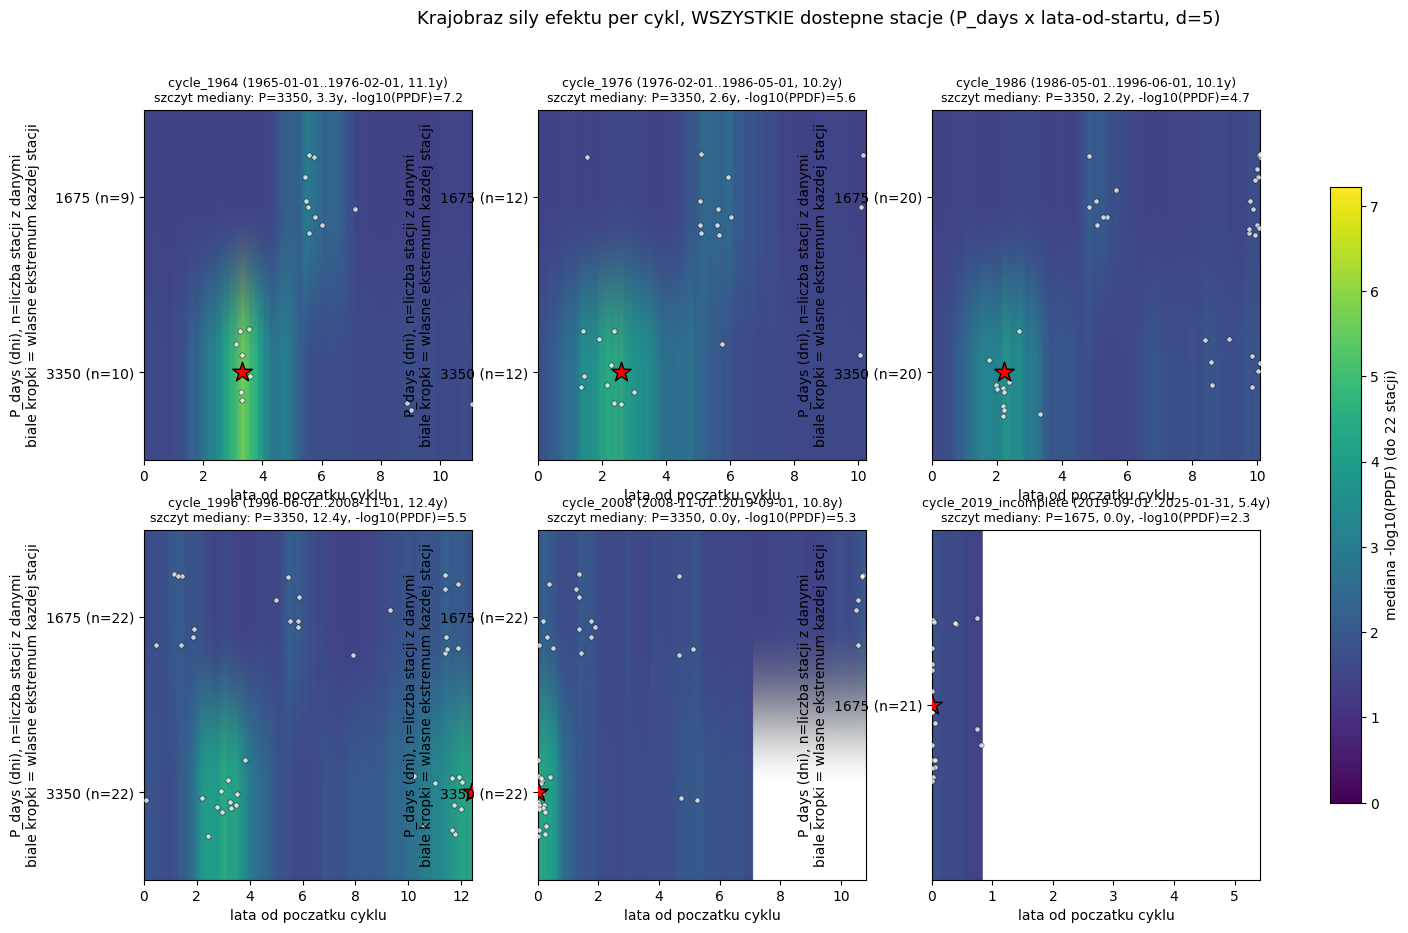

In [4]:
# CZESC A, krok 3: siatka 2x3 (6 cykli), kazdy panel = heatmapa 2 wierszy
# (P_days=1675/3350) x lata-od-startu, mediana po WSZYSTKICH dostepnych
# stacjach + nalozony punktowy rozrzut (kazda stacja osobno, mala kropka,
# przezroczysta) pokazujacy WLASNE ekstremum kazdej stacji. Jesli kropki sa
# ciasno skupione kolo jasnego pasa - zgoda miedzy stacjami jest realna, nie
# tylko efekt usredniania. Jesli kropki sa rozrzucone szeroko mimo jasnego
# pasa na medianie - ostroznie z interpretacja "pasa" jako wspolnego sygnalu
# wszystkich stacji.
def plot_allstations_heatmaps(d, vmax, save_suffix):
    cycles_order = list(CYCLE_BOUNDS.keys())
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    im = None
    for ax, cycle in zip(axes.flat, cycles_order):
        p_days_values, years, mat, n_stations, peaks = build_cycle_heatmap_22(cycle, d)
        if len(p_days_values) == 0:
            ax.set_visible(False)
            continue
        im = ax.imshow(
            mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax,
            extent=[years.min(), years.max(), len(p_days_values) - 0.5, -0.5],
        )
        ax.set_yticks(range(len(p_days_values)))
        ax.set_yticklabels([f"{p} (n={n})" for p, n in zip(p_days_values, n_stations)])
        ax.set_ylim(len(p_days_values) - 0.5, -0.5)

        row_of = {p: i for i, p in enumerate(p_days_values)}
        rng = np.random.default_rng(0)
        jitter = rng.uniform(-0.25, 0.25, size=len(peaks))
        ax.scatter(
            peaks["years_since_start"], peaks["P_days"].map(row_of) + jitter,
            s=14, color="white", edgecolor="black", linewidth=0.4, alpha=0.75, zorder=4,
        )

        if np.isfinite(mat).any():
            flat_i = np.nanargmax(mat)
            pi, ti = np.unravel_index(flat_i, mat.shape)
            peak_val = mat[pi, ti]
            ax.scatter([years[ti]], [pi], marker="*", s=220, color="red", edgecolor="black", zorder=5)
            peak_note = f"szczyt mediany: P={p_days_values[pi]}, {years[ti]:.1f}y, -log10(PPDF)={peak_val:.1f}"
        else:
            peak_note = "brak danych"

        length_y = CYCLE_LENGTH_DAYS[cycle] / 365.25
        ax.set_title(
            f"{cycle} ({CYCLE_START[cycle].date()}..{CYCLE_END[cycle].date()}, {length_y:.1f}y)\n{peak_note}",
            fontsize=9,
        )
        ax.set_xlabel("lata od poczatku cyklu")
        ax.set_ylabel("P_days (dni), n=liczba stacji z danymi\nbiale kropki = wlasne ekstremum kazdej stacji")

    for ax in axes.flat[len(cycles_order):]:
        ax.set_visible(False)
    if im is not None:
        fig.colorbar(im, ax=axes, label="mediana -log10(PPDF) (do 22 stacji)", shrink=0.8)
    fig.suptitle(
        f"Krajobraz sily efektu per cykl, WSZYSTKIE dostepne stacje (P_days x lata-od-startu, d={d})",
        fontsize=13,
    )
    fig.savefig(f"{RESULTS_DIR}/allstations_heatmap_by_cycle_{save_suffix}.png", dpi=120, bbox_inches="tight")
    plt.show()


plot_allstations_heatmaps(5, VMAX_D5_22, "d5")

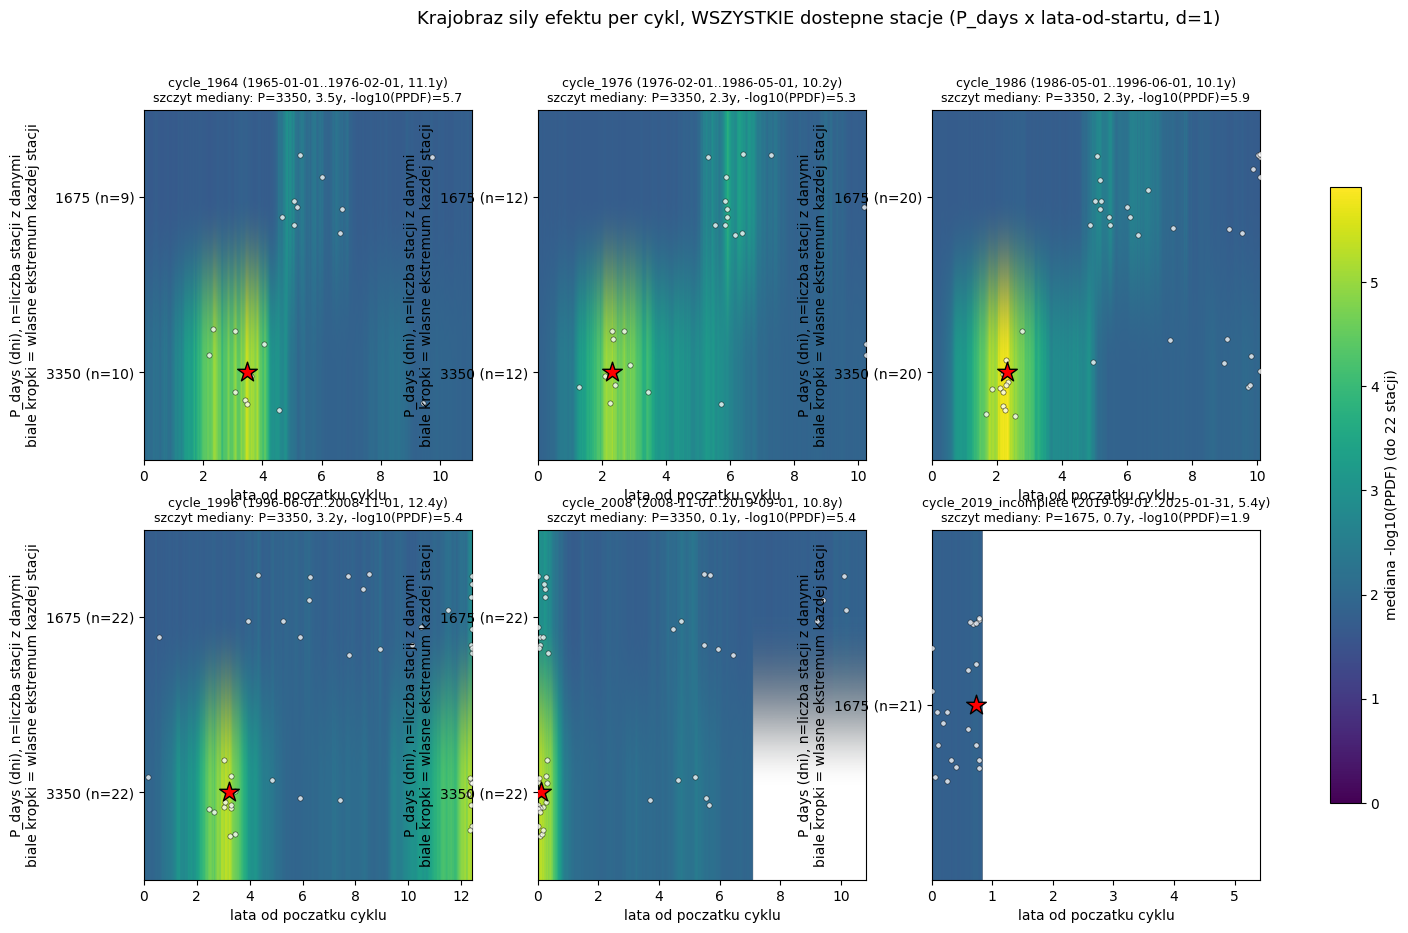

In [5]:
# To samo dla d=1 (kontrola przy innej szerokosci binu, jak w 20260823b.ipynb).
plot_allstations_heatmaps(1, VMAX_D1_22, "d1")

In [6]:
# CZESC A, krok 4: liczbowe podsumowanie - ile z DOSTEPNYCH (nie zawsze 22)
# stacji bije prog referencyjny Homoli (log10(PPDF) < -8) per cykl x P_days,
# osobno per d. Rozszerza tabele z 20260822.txt pkt 16 (tam liczone bylo
# najlepsze P_days per stacja/cykl razem) o rozbicie na P_days=1675 vs 3350
# oddzielnie - zeby bezposrednio widziec, czy anomalia cyklu 2008 (najpierw
# zauwazona na 5 stacjach) utrzymuje sie liczbowo na pelnym zestawie.
HOMOLA_LOG10_PPDF_BENCHMARK = -8

hitrate_rows = []
for cycle in CYCLE_BOUNDS:
    for d in (1, 5):
        for P_days in P_DAYS_ALLSTATIONS:
            sub = all_candidates_22[
                (all_candidates_22["cycle"] == cycle)
                & (all_candidates_22["d"] == d)
                & (all_candidates_22["P_days"] == P_days)
            ]
            if len(sub) == 0:
                continue
            best_per_station = sub.groupby("station")["PPDF"].min()
            log10_best = np.log10(best_per_station.replace(0, np.nan))
            n_stations = len(best_per_station)
            n_hits = int((log10_best < HOMOLA_LOG10_PPDF_BENCHMARK).sum())
            hitrate_rows.append(dict(
                cycle=cycle, d=d, P_days=P_days,
                n_stations=n_stations, n_hits=n_hits,
                hit_rate=n_hits / n_stations if n_stations else np.nan,
                strongest_log10_PPDF=log10_best.min() if n_stations else np.nan,
                strongest_station=log10_best.idxmin() if n_stations else None,
            ))

hitrate = pd.DataFrame(hitrate_rows).sort_values(["d", "P_days", "cycle"])
pd.set_option("display.width", 160)
print(hitrate.to_string(index=False))
hitrate.to_csv(f"{RESULTS_DIR}/allstations_cycle_hitrate_by_Pdays.csv", index=False)

                cycle  d  P_days  n_stations  n_hits  hit_rate  strongest_log10_PPDF strongest_station
           cycle_1964  1    1675           9       0  0.000000             -5.905033              hrms
           cycle_1976  1    1675          12       2  0.166667             -8.621868              aatb
           cycle_1986  1    1675          20       0  0.000000             -5.966914              jung
           cycle_1996  1    1675          22       1  0.045455            -11.317489              sopb
           cycle_2008  1    1675          22       0  0.000000             -5.825287              thul
cycle_2019_incomplete  1    1675          21       0  0.000000             -3.649521              pwnk
           cycle_1964  1    3350          10       2  0.200000            -14.392060              hrms
           cycle_1976  1    3350          12       2  0.166667            -11.065066              aatb
           cycle_1986  1    3350          20       1  0.050000           

In [7]:
# CZESC B, krok 1: wczytanie danych 5 stacji reprezentatywnych x 8 wartosci
# P_days (cycle_scan_* dla 1675/3350 + pgrid_scan_* dla pozostalych 6) -
# DOKLADNIE to samo zrodlo co 20260823b.ipynb (kopiowane, nie importowane -
# konwencja samodzielnosci notebookow tego repo).
FILENAME_RE_5 = re.compile(
    r"^(?P<prefix>cycle_scan|pgrid_scan)_(?P<station>[a-z]+)_(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)\.csv$"
)


def parse_result_filename_5(path):
    m = FILENAME_RE_5.match(os.path.basename(path))
    if not m or m["station"] not in STATIONS_5 or m["cycle"] not in CYCLE_BOUNDS:
        return None
    return dict(station=m["station"], cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


frames_5 = []
paths_5 = sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv")) +
                  glob.glob(os.path.join(RESULTS_DIR, "pgrid_scan_*.csv")))
for path in paths_5:
    meta = parse_result_filename_5(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["cycle"] = meta["cycle"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames_5.append(df)

all_candidates_5 = pd.concat(frames_5, ignore_index=True)
print(f"Wczytano {len(all_candidates_5)} wierszy z {len(frames_5)} plikow (5 stacji, siatka P_days)")

Wczytano 1196172 wierszy z 344 plikow (5 stacji, siatka P_days)


In [8]:
# CZESC B, krok 2: dla kazdego (cykl, d, P_days) - pozycja (w latach-od-startu)
# maksimum MEDIANY -log10(PPDF) po 5 stacjach (dokladnie to, co 20260823b.ipynb
# rysowal jako heatmape - tutaj tylko wyciagamy WSPOLRZEDNA szczytu w kazdym
# wierszu P_days, zamiast tylko patrzec na obrazek). Nastepnie per cykl (i d)
# dopasowanie regresji liniowej: lata-od-startu-szczytu ~ P_days. Nachylenie
# (slope) ILOSCIOWO odpowiada "jak szybko szczyt przesuwa sie w prawo wraz ze
# wzrostem P_days" - to jest liczba do porownania miedzy cyklami (w tym cykl
# 2008 vs pozostale 4), zamiast oceny wzrokowej z 20260823b.ipynb.
def ridge_points_for_cycle(cycle, d):
    cyc = all_candidates_5[(all_candidates_5["cycle"] == cycle) & (all_candidates_5["d"] == d)]
    t0_ref = pd.date_range(CYCLE_START[cycle], CYCLE_END[cycle], freq="24h")
    years_since_start = (t0_ref - CYCLE_START[cycle]).days / 365.25

    points = []
    for P_days, sub in cyc.groupby("P_days"):
        med_ppdf = sub.groupby("t0")["PPDF"].median().reindex(t0_ref)
        if med_ppdf.notna().sum() == 0:
            continue
        with np.errstate(divide="ignore"):
            neglog = -np.log10(np.clip(med_ppdf.to_numpy(dtype=float), 1e-300, None))
        if not np.isfinite(neglog).any():
            continue
        ti = np.nanargmax(neglog)
        points.append((P_days, years_since_start[ti], neglog[ti]))
    return pd.DataFrame(points, columns=["P_days", "peak_years_since_start", "peak_neglog10_ppdf"])


MIN_POINTS_FOR_FIT = 4  # ponizej tego regresja liniowa jest niewiele warta

ridge_rows = []
ridge_points_all = {}
for cycle in CYCLE_BOUNDS:
    for d in (1, 5):
        pts = ridge_points_for_cycle(cycle, d)
        ridge_points_all[(cycle, d)] = pts
        if len(pts) < MIN_POINTS_FOR_FIT:
            ridge_rows.append(dict(cycle=cycle, d=d, n_points=len(pts), slope_years_per_1000d=np.nan,
                                    intercept_years=np.nan, r_value=np.nan, p_value=np.nan))
            continue
        fit = linregress(pts["P_days"], pts["peak_years_since_start"])
        ridge_rows.append(dict(
            cycle=cycle, d=d, n_points=len(pts),
            slope_years_per_1000d=fit.slope * 1000,
            intercept_years=fit.intercept,
            r_value=fit.rvalue, p_value=fit.pvalue,
        ))

ridge_summary = pd.DataFrame(ridge_rows).sort_values(["d", "cycle"])
pd.set_option("display.width", 160)
print(ridge_summary.to_string(index=False))
ridge_summary.to_csv(f"{RESULTS_DIR}/pgrid_ridge_slope_by_cycle.csv", index=False)

                cycle  d  n_points  slope_years_per_1000d  intercept_years   r_value      p_value
           cycle_1964  1         8              -2.227391        10.825429 -0.981669 1.518765e-05
           cycle_1976  1         8              -1.917817         9.242495 -0.982171 1.397867e-05
           cycle_1986  1         8              -2.165055         9.553097 -0.985158 8.082806e-06
           cycle_1996  1         8              -3.544121        15.230981 -0.880655 3.878302e-03
           cycle_2008  1         8              -0.096938         0.377720 -0.795902 1.813398e-02
cycle_2019_incomplete  1         1                    NaN              NaN       NaN          NaN
           cycle_1964  5         8              -1.366400         7.807285 -0.998894 3.377422e-09
           cycle_1976  5         8              -2.134342         9.803646 -0.979438 2.140017e-05
           cycle_1986  5         8              -1.913394         8.347313 -0.986614 5.935774e-06
           cycle_199

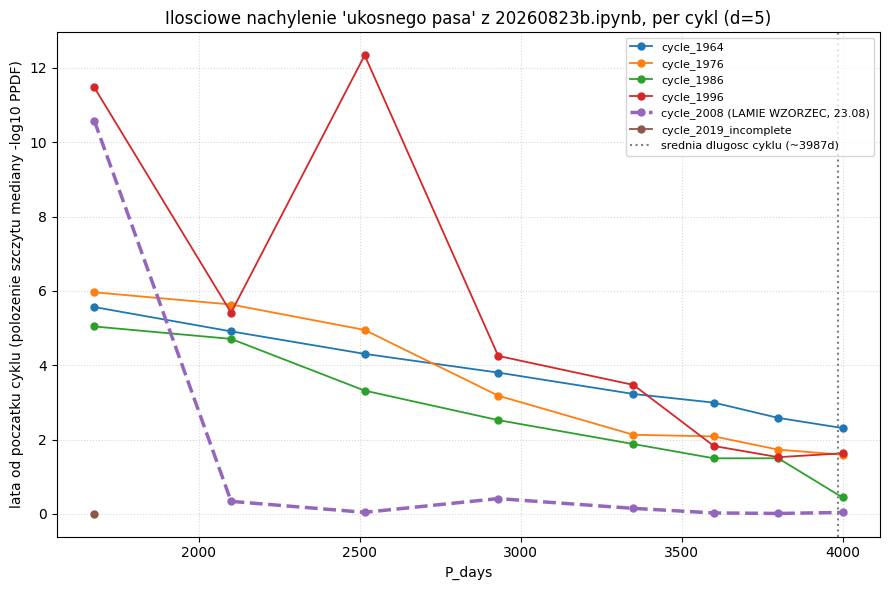

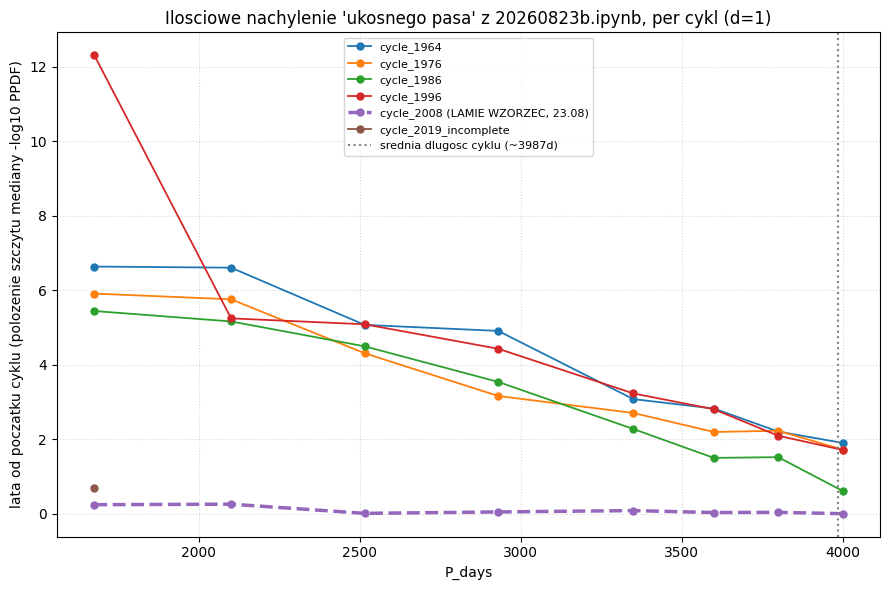

In [9]:
# CZESC B, krok 3: wizualizacja - dla kazdego d osobny wykres, os X = P_days,
# os Y = lata-od-startu-cyklu polozenia szczytu, jeden kolor/linia na cykl +
# dopasowana prosta (przez ciagle punkty). cycle_2008 narysowany grubsza,
# przerywana linia - bezposrednie porownanie wzrokowe z ilosciowym
# nachyleniem z tabeli wyzej.
def plot_ridge(d, save_suffix):
    fig, ax = plt.subplots(figsize=(9, 6))
    for cycle in CYCLE_BOUNDS:
        pts = ridge_points_all[(cycle, d)]
        if len(pts) == 0:
            continue
        is_2008 = cycle == "cycle_2008"
        ax.plot(
            pts["P_days"], pts["peak_years_since_start"],
            marker="o", ms=5,
            lw=2.5 if is_2008 else 1.3,
            ls="--" if is_2008 else "-",
            label=f"{cycle}{' (LAMIE WZORZEC, 23.08)' if is_2008 else ''}",
        )
    ax.axvline(3987, color="gray", ls=":", label="srednia dlugosc cyklu (~3987d)")
    ax.set_xlabel("P_days")
    ax.set_ylabel("lata od poczatku cyklu (polozenie szczytu mediany -log10 PPDF)")
    ax.set_title(f"Ilosciowe nachylenie 'ukosnego pasa' z 20260823b.ipynb, per cykl (d={d})")
    ax.legend(fontsize=8)
    ax.grid(ls=":", alpha=0.5)
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/pgrid_ridge_slope_scatter_{save_suffix}.png", dpi=120)
    plt.show()


plot_ridge(5, "d5")
plot_ridge(1, "d1")